# Lab 7 — wariant

Obraz: paski ukośne. Audio: fala prostokątna 500 Hz (harmoniki).


## 1. Importy


In [17]:
%matplotlib inline
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from scipy.io.wavfile import write
from scipy.signal import butter, filtfilt

try:
    import cv2
except ImportError:
    cv2 = None

OUT_DIR = Path.cwd()



## 2. Generowanie obrazu — paski ukośne


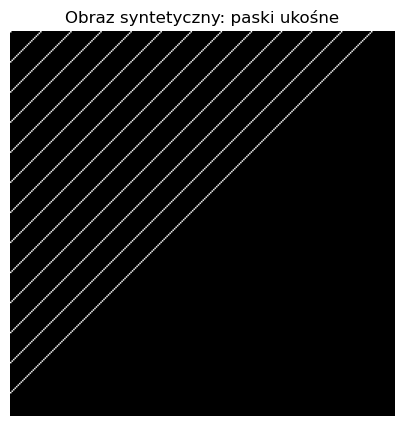

In [18]:
def draw_line_bresenham(img, x0, y0, x1, y1, val=255):
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    x, y = x0, y0
    h, w = img.shape
    while True:
        if 0 <= x < w and 0 <= y < h:
            img[y, x] = val
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x += sx
        if e2 < dx:
            err += dx
            y += sy


def generate_diagonal_stripes(size=256, spacing=20):
    img = np.zeros((size, size), dtype=np.uint8)
    for i in range(0, size, spacing):
        if cv2 is not None:
            cv2.line(img, (i, 0), (0, i), 255, 1)
        else:
            draw_line_bresenham(img, i, 0, 0, i, 255)
    return img


size, spacing = 256, 20
image = generate_diagonal_stripes(size, spacing)

img_path = OUT_DIR / "diagonal_stripes.png"
if cv2 is not None:
    cv2.imwrite(str(img_path), image)
else:
    plt.imsave(str(img_path), image, cmap="gray", vmin=0, vmax=255)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Obraz syntetyczny: paski ukośne")
plt.axis("off")
plt.show()


## 3. DFT 2D obrazu i widmo amplitudy


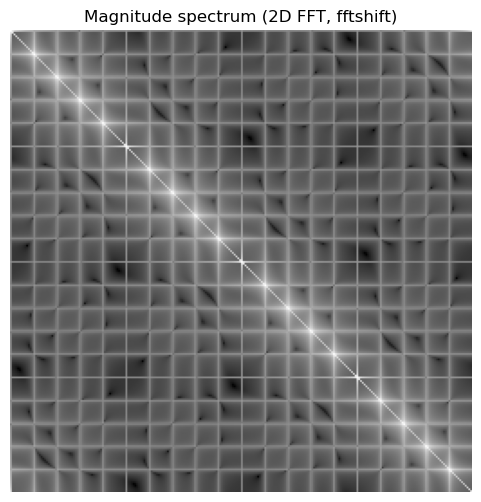

In [19]:
f = np.fft.fft2(image.astype(np.float64))
fshift = np.fft.fftshift(f)

# Skala logarytmiczna widma
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Magnitude spectrum (2D FFT, fftshift)")
plt.axis("off")
plt.show()


## 4. Filtr dolnoprzepustowy w dziedzinie częstotliwości


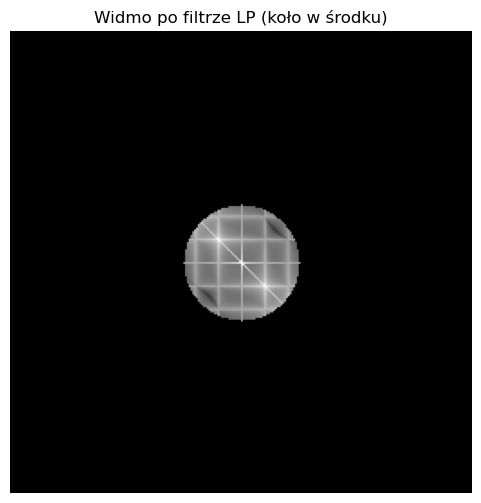

In [20]:
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2
r = rows // 8

yy, xx = np.ogrid[:rows, :cols]
mask_lp = ((xx - ccol) ** 2 + (yy - crow) ** 2 <= r**2).astype(np.float64)

fshift_lp = fshift * mask_lp

plt.figure(figsize=(6, 6))
plt.imshow(20 * np.log(np.abs(fshift_lp) + 1), cmap="gray")
plt.title("Widmo po filtrze LP (koło w środku)")
plt.axis("off")
plt.show()


## 5. Odtworzenie obrazu — odwrotna DFT


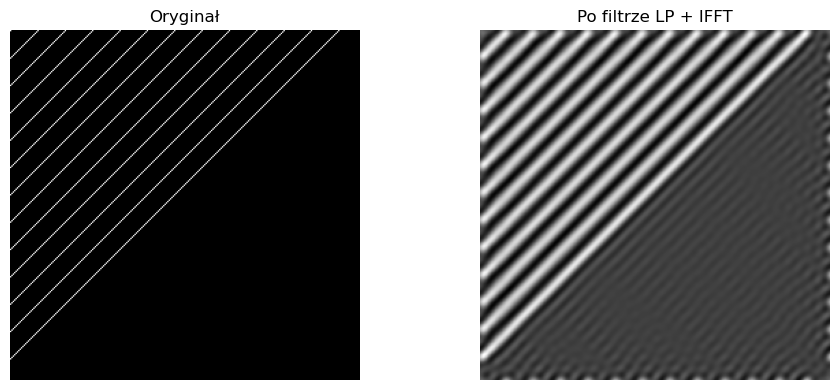

In [21]:
f_ishift = np.fft.ifftshift(fshift_lp)
img_back = np.fft.ifft2(f_ishift)
img_back = np.real(img_back)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Oryginał")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_back, cmap="gray")
plt.title("Po filtrze LP + IFFT")
plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Audio: fala prostokątna 500 Hz z harmonicznych


In [22]:
def square_wave_from_harmonics(t, f0=500.0, num_odd=50):
    """(4/pi) * sum sin(2*pi*(2k+1)*f0*t)/(2k+1)"""
    w0 = 2 * np.pi * f0
    y = np.zeros_like(t, dtype=np.float64)
    for k in range(num_odd):
        n = 2 * k + 1
        y += np.sin(n * w0 * t) / n
    y *= 4 / np.pi
    return np.clip(y, -1.0, 1.0)


fs = 44100
duration = 3.0
f0 = 500.0
t = np.linspace(0.0, duration, int(fs * duration), endpoint=False)
y = square_wave_from_harmonics(t, f0=f0, num_odd=50)

wav_path = OUT_DIR / "square_wave_500hz_harmonics.wav"
write(str(wav_path), fs, (y * 32767).astype(np.int16))
print("Zapisano:", wav_path.resolve())


Zapisano: /Users/bartosz/UBB/DSP/Lab 7/square_wave_500hz_harmonics.wav


## 7. Przebieg czasowy i widmo 1D (porównanie dziedzin)


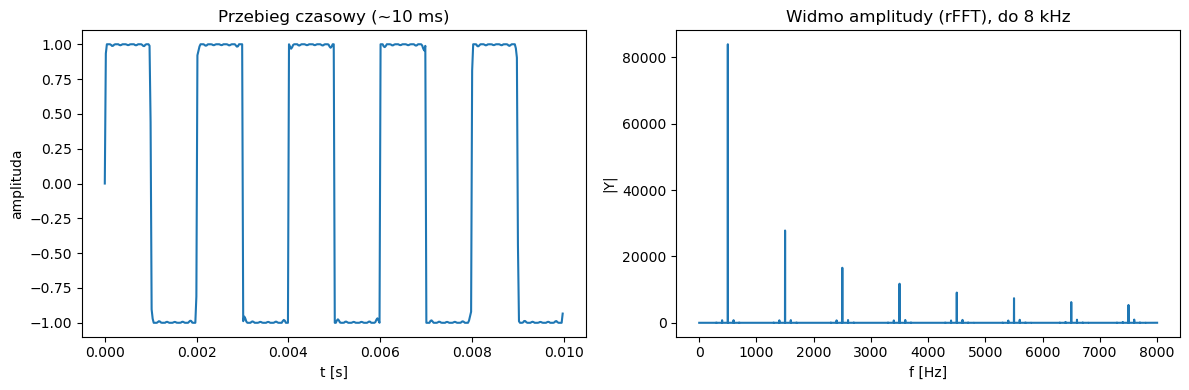

In [23]:
Y = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), 1.0 / fs)
mag = np.abs(Y)

n_show = int(0.01 * fs)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t[:n_show], y[:n_show])
plt.title("Przebieg czasowy (~10 ms)")
plt.xlabel("t [s]")
plt.ylabel("amplituda")
plt.subplot(1, 2, 2)
idx = freqs <= 8000
step = max(1, len(freqs[idx]) // 4000)
plt.plot(freqs[idx][::step], mag[idx][::step])
plt.title("Widmo amplitudy (rFFT), do 8 kHz")
plt.xlabel("f [Hz]")
plt.ylabel("|Y|")
plt.tight_layout()
plt.show()


## 8. Filtracja audio

Filtr dolnoprzepustowy w dziedzinie czasu (Butterworth, `filtfilt`).


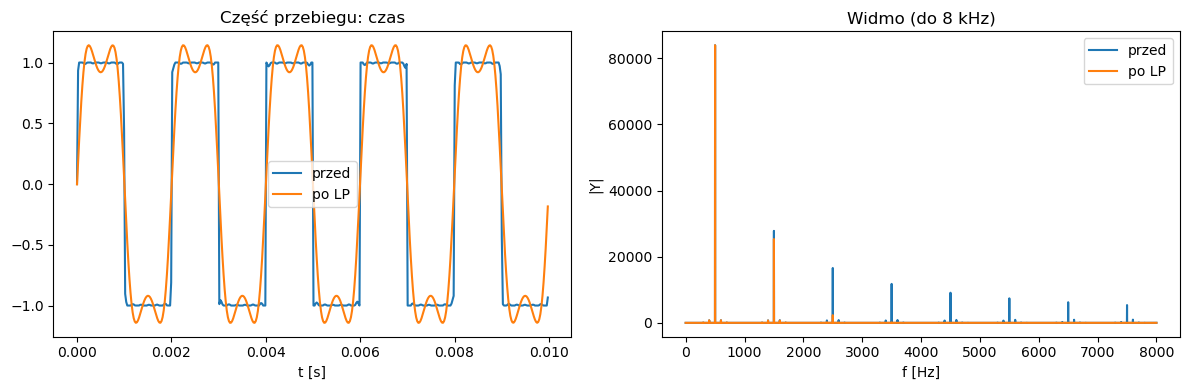

In [24]:
nyq = 0.5 * fs
cutoff_hz = 2000.0
wn = min(cutoff_hz / nyq, 0.99)
b, a = butter(4, wn, btype="low", analog=False)
y_lp = filtfilt(b, a, y)

Y_lp = np.fft.rfft(y_lp)
mag_lp = np.abs(Y_lp)

n_show = int(0.01 * fs)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t[:n_show], y[:n_show], label="przed")
plt.plot(t[:n_show], y_lp[:n_show], label="po LP")
plt.legend()
plt.title("Część przebiegu: czas")
plt.xlabel("t [s]")
plt.subplot(1, 2, 2)
idx = freqs <= 8000
step = max(1, len(freqs[idx]) // 4000)
plt.plot(freqs[idx][::step], mag[idx][::step], label="przed")
plt.plot(freqs[idx][::step], mag_lp[idx][::step], label="po LP")
plt.legend()
plt.title("Widmo (do 8 kHz)")
plt.xlabel("f [Hz]")
plt.ylabel("|Y|")
plt.tight_layout()
plt.show()
